In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

## An Interacting Affine model of the dark sector

##### $P_X = w\rho_X-(1+w)\rho_\Lambda$ 
##### $w_x = w-(1+w)\frac{\rho_\Lambda}{\rho_X}$

### Using cosmological constant normalisation

$x =\frac{\rho_X}{\rho_\Lambda}$ , $y=\frac{\rho_m}{\rho_\Lambda}$

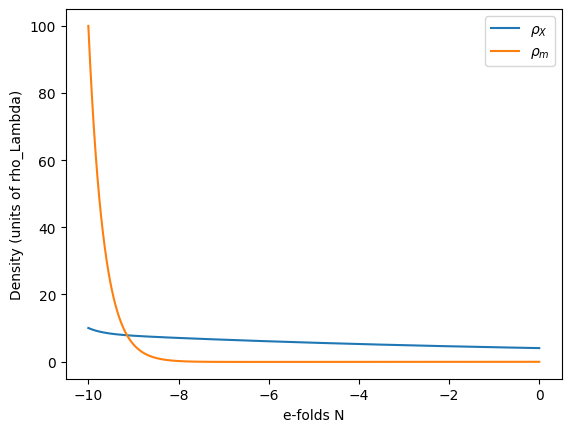

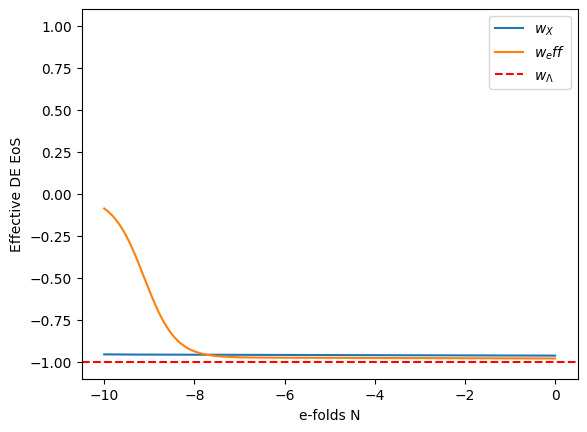

In [2]:
# Parameters to be optimised to lambda cdm data
w = -0.95
q = 0.05


def system(N, vars):
    x, y = vars

    w_x = w - (1 + w)/(x+1e-8)
    
    dx =-3*(1+w)*(x-1) + q*(x-y)
    dy =-3*y - q*(x-y)

    return [dx, dy]

N = np.linspace(-10, 0, 500) # -50 epochs is around the time of inflation but for observational data fitting i need to start today slightly back -10-0 epochs
sol = solve_ivp(system, [-10,0], [10,100] , t_eval=N)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
#large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
a = np.exp(sol.t)  # scale factor


rho_X = x * 1  # assuming rho_Lambda = 1 in code units
rho_m = y * 1
rho_tot = rho_X + rho_m + 1
w_x = w - (1 + w)/(x+1e-8)
w_eff = (w*(x-1)-1) /(x+y)

plt.figure()
plt.plot(N, x, label=r'$\rho_X$')
plt.plot(N, y, label=r'$\rho_m$')
plt.xlabel('e-folds N')
plt.ylabel('Density (units of rho_Lambda)')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(N, w_x, label=r'$w_X$')
plt.plot(N, w_eff, label=r'$w_eff$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Physical fixed points: [[1.0350877192982457, -0.017543859649122806]]
Fixed points (1.0350877192982457,-0.017543859649122806)
Eigen Values: [-1.44833518 -2.95166482]
Type=node
Stability=Attractor



/tmp/ipykernel_2301/90627675.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


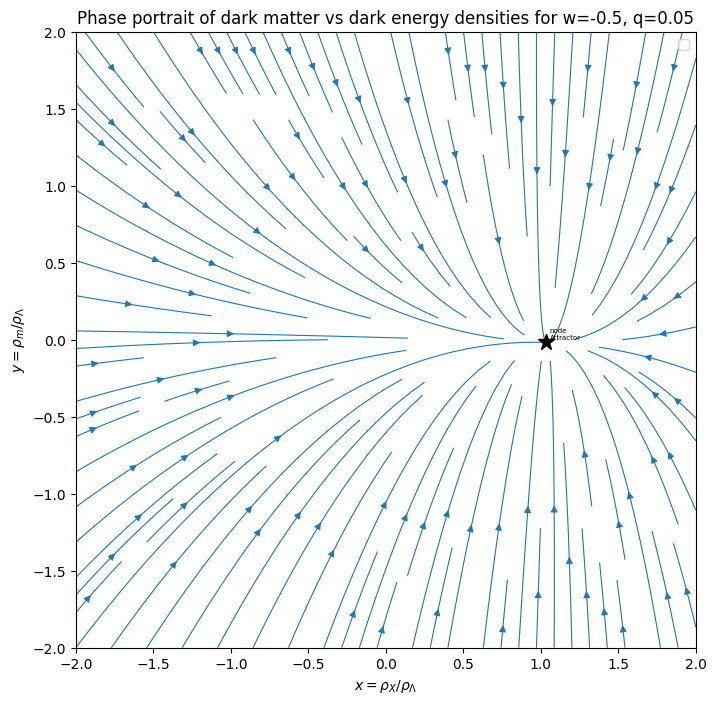

In [3]:
#plotting phase portrait at lambda slice
def phase_plot(w, q):
  def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
  initialState=np.array([10, 100])

  simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

  def stop_event(t, y):
      x, y_ = y
      return abs(x) - 1e-6  # stop near singularity

  stop_event.terminal = True

  sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
  dx = sol.y[0]
  dy = sol.y[1]
  a = np.exp(sol.t)  # scale factor

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-2,2,10)
  x1 = np.linspace(-2,2,10)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
              dx,dy= system(0,[X0[i,j], X1[i,j]])
              dX0[i,j] = dx
              dX1[i,j] = dy

# in order to plot trajectories of solutions from fixed points, using sympy to solve the equations dx and dy =0 and 
# finding values of x and y. These can then be used in a jaconian matrix to determine eigenvalues at these fixed points which 
# determines stability.  

  x_FP, y_FP = sp.symbols('x y ', real=True)

  #w_x = w_a - (1 + w_a)/x_FP
  f =-3*(1+w)*(x_FP-1) + q*(x_FP-y_FP)
  g =-3*y_FP - q*(x_FP-y_FP)
  J_sym = sp.Matrix([f, g]).jacobian([x_FP, y_FP]) # Symbolic Jacobian for x and y 2D

  solutions = sp.solve([f, g], [x_FP, y_FP], dict=True)
  FP=[]
  for sol in solutions:
    if x_FP in sol and y_FP in sol:
      x_val = sol[x_FP]
      y_val = sol[y_FP]
      #z_val = sol[z_FP]
      #lam_val = sol[lam_FP]
      if x_val.is_real and y_val.is_real:
          x_val,y_val = float(x_val),float(y_val)
          FP.append([float(x_val),float(y_val)])
  print("Physical fixed points:", FP)

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')


# classifying E vals in accordance with dynamical system analysis
  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

# plotting the fixed points by determining their eigenvalues and then classifying them using the above function
  for fp in FP:
    x_c, y_c = fp
    J_num = np.array(J_sym.subs({x_FP: x_c,y_FP: y_c}),dtype=float)
    eigvals,eigvecs = np.linalg.eig(J_num)
    stability,point_type = classify_FP(eigvals)
    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=5)

# a separatrix is plotted from a saddle point and divides areas of different dynamics along the eigenvector direction


    if stability=='saddle': 
       delta=1e-5 # small perturbations along eigenvector
       for vector,value in zip(eigvecs.T,eigvals):
          if value>0:
             for pm in [-1,1]: #either positive of negative direction
              x_start = np.array([x_c,y_c])+pm*delta*vector[:2]
              trajectory= solve_ivp(fun=system,t_span=(simulationTime[0], simulationTime[-1]),y0=x_start,t_eval=simulationTime,method='RK45',events=stop_event)
              plt.plot(trajectory.y[0],trajectory.y[1],'r--',linewidth=1)
    

  plt.xlabel(r"$x = \rho_X/ \rho_\Lambda$")
  plt.ylabel(r"$y=\rho_m/ \rho_\Lambda$")
  plt.title(rf"Phase portrait of dark matter vs dark energy densities for w={w}, q={q}")
  #plt.xlim(-1.5,1.5)
  #plt.ylim(-1.5,1.5)
  plt.legend()
  plt.show()





# try w=-0.95 and -0.5 and q=+- 0.05
phase_plot(-0.5,0.05)

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018/meta


#### Plot of x vs y vs $w_{eff}$

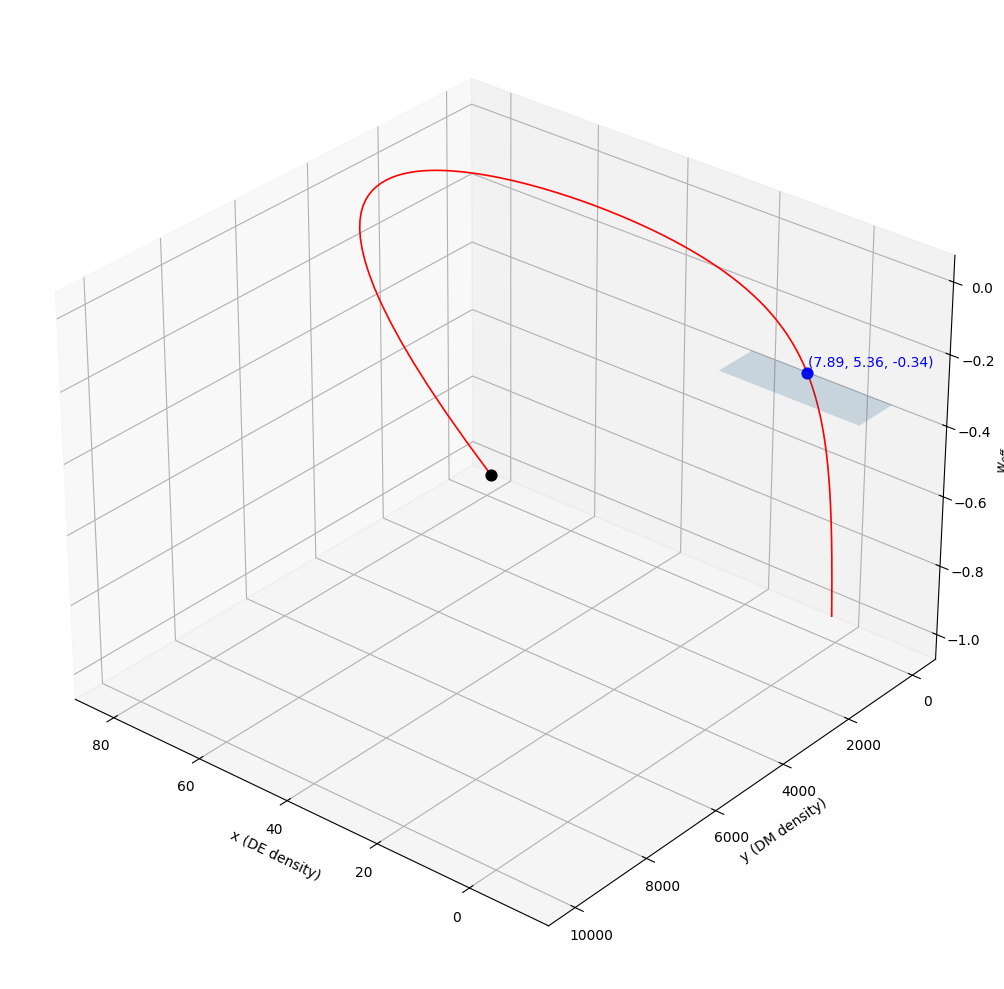

In [4]:
w,q=-0.5,-0.05



def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
initialState=np.array([1, 10000]) # x~1   y=y0e^-3N~1e13

simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
weff=((w*(x-1)-1)/(x+y))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, y, weff, color='r', lw=1.2)
ax.scatter3D(x[0], y[0], weff[0], color='black', s=60)

a = np.linspace(-10, 20, 100)
b = np.linspace(-10, 1000, 10000)
X, Y = np.meshgrid(a, b)
Z = np.ones(X.shape) * -1/3
ax.plot_surface(X, Y, Z, alpha=0.2)

idx = np.where(np.isclose(weff, -1/3, atol=3e-3))[0]
for i in idx:
    ax.scatter3D(x[i], y[i], weff[i], color='blue', s=60)
    ax.text(x[i]+0.02, y[i]+0.02, weff[i]+0.02, f"({x[i]:.2f}, {y[i]:.2f}, {weff[i]:.2f})", color='b')

      

ax.set_xlabel("x (DE density)")
ax.set_ylabel("y (DM density)")
ax.set_zlabel("$w_{eff}$")
ax.view_init(elev=30, azim=130)
plt.tight_layout()
plt.show()

## Using H normalised variables
#### from the affine equation of state we find $\rho_X=\rho_{dyn}+\rho_\Lambda$
#### so the Friedmann equation, $H^2 = 1/3 (\rho_m+\rho_X) =1/3 (\rho_{dyn}+\rho_m +\rho_\Lambda)$, becomes 1=x+y+z where:

#### $x=\frac{\rho_{dyn}}{3H^2}$, $y=\frac{\rho_{m}}{3H^2}$, $z=\frac{\rho_{\Lambda}}{3H^2}$
#### using these variables, we find that the continuity equations become a 2D system using the Friedmann constaint z=1-x-y and using the interaction term $Q=qH(\rho_X-\rho_m)$

#### $x' = 3(1+w)(x^2-x)+3xy+q(1-2y)$
#### $y' = 3(y^2-y)+3xy(1+w) -q(1-2y)$

#### $w_{eff} = \frac{P_X}{\rho_X+\rho_m}=\frac{w(\rho_X-\rho_\Lambda)-\rho_\Lambda}{\rho_X+\rho_m}$
#### $w_{eff} = \frac{wx-z}{x+y+z}= (1+w)x+y-1$

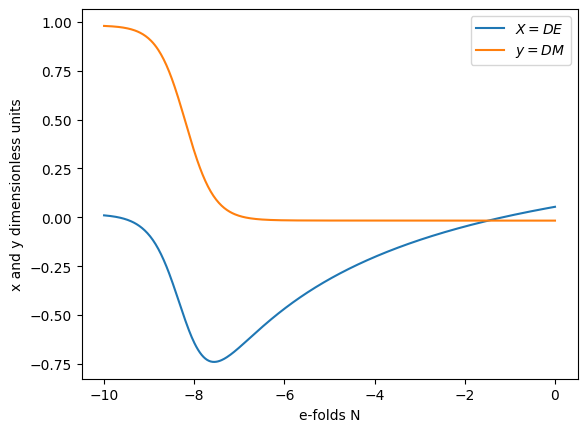

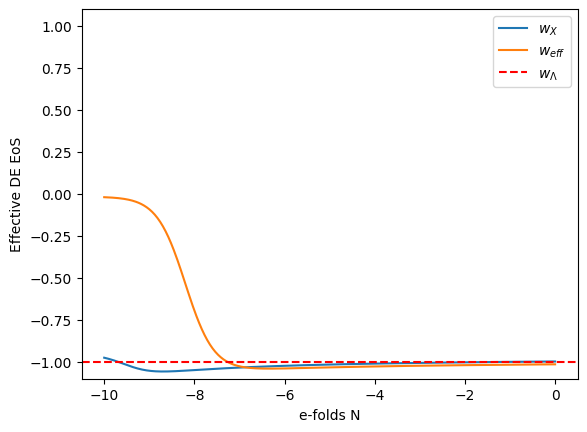

In [5]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    return [dx,dy]

simulationTime=np.linspace(-10,0,500)
solution = solve_ivp(system,[-10,0],[0.01,0.98],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
wx= ((1+w)*x +y-1)/(1-y+1e-6)
weff=(1+w)*x +y-1
#wx = np.full_like(x, np.nan)
#mask = x > 1e-3
#wx[mask] = w - (1+w)*(1 - x[mask] - y[mask]) / x[mask]


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.xlabel('e-folds N')
plt.ylabel('x and y dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

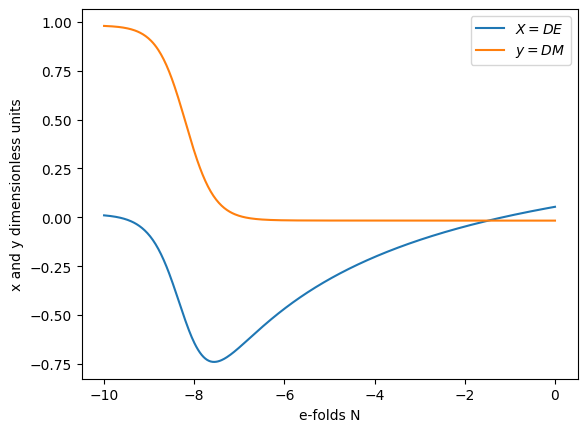

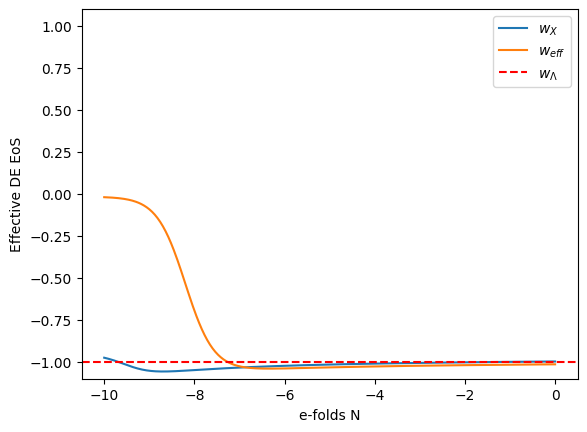

In [6]:
w,q =-0.95,0.05
wr=1/3

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]

simulationTime=np.linspace(-10,0,500)
solution = solve_ivp(system,[-10,0],[0.01,0.98],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
wx= ((1+w)*x +y-1)/(1-y+1e-6)
weff=(1+w)*x +y-1
#wx = np.full_like(x, np.nan)
#mask = x > 1e-3
#wx[mask] = w - (1+w)*(1 - x[mask] - y[mask]) / x[mask]


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.xlabel('e-folds N')
plt.ylabel('x and y dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

### Includes radiation factor

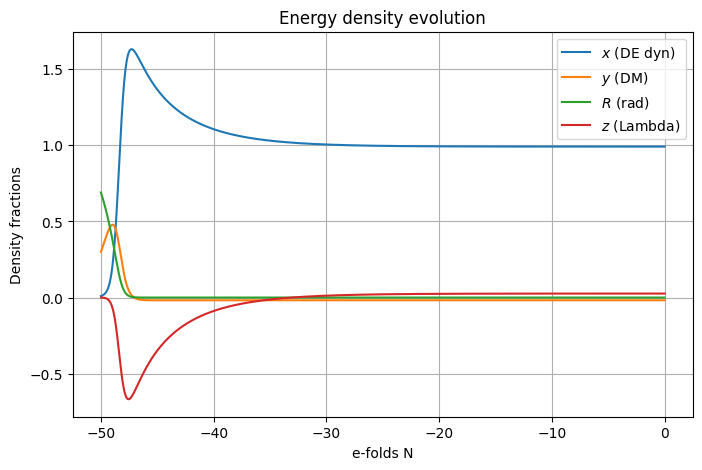

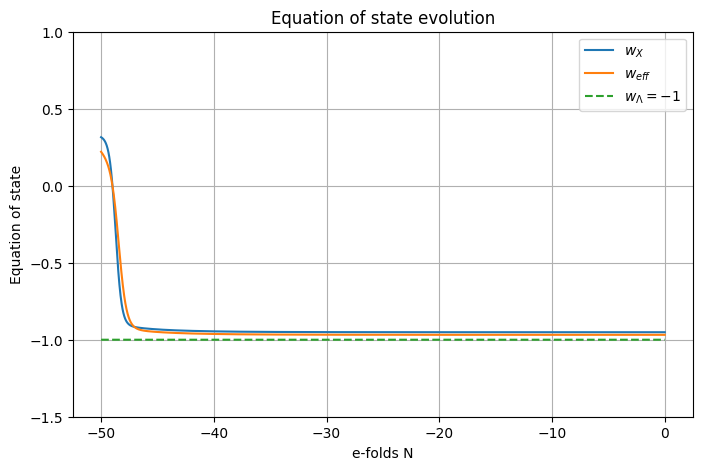

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# parameters
w = -0.95
q = 0.05

# system in e-fold time N
def system(N, vars):
    x, y, R = vars

    z = 1 - x - y - R

    dx = -3*(1+w)*(x**2 - x) + 3*x*y + 4*x*R + q*(1 - 2*y - R)
    dy = -3*y - q*(1 - 2*y - R) + 3*(1+w)*x*y + 3*y**2 + 4*y*R
    dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dR]


# time range (back to radiation era)
simulationTime = np.linspace(-50, 0, 2000)

# initial conditions (early radiation + matter dominated)
y0 = [0.01, 0.3, 0.69]   # x, y, R

sol = solve_ivp(system, [-50, 0], y0, t_eval=simulationTime)

x = sol.y[0]
y = sol.y[1]
R = sol.y[2]

# derived variables
z = 1 - x - y - R

# equation of state of dynamic DE
wX = ((w+1)*x + y + (4/3)*R - 1) / (1 - y + 1e-8)

# effective EOS
weff = (w+1)*x + y + (4/3)*R - 1

w_lambda = -1 * np.ones_like(simulationTime)


# -----------------------------
# PLOT 1: densities
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(simulationTime, x, label=r'$x$ (DE dyn)')
plt.plot(simulationTime, y, label=r'$y$ (DM)')
plt.plot(simulationTime, R, label=r'$R$ (rad)')
plt.plot(simulationTime, z, label=r'$z$ (Lambda)')
plt.xlabel("e-folds N")
plt.ylabel("Density fractions")
plt.legend()
plt.title("Energy density evolution")
plt.grid()


# -----------------------------
# PLOT 2: equations of state
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(simulationTime, wX, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.plot(simulationTime, w_lambda, '--', label=r'$w_\Lambda = -1$')
plt.xlabel("e-folds N")
plt.ylabel("Equation of state")
plt.ylim(-1.5, 1.0)
plt.legend()
plt.title("Equation of state evolution")
plt.grid()

plt.show()

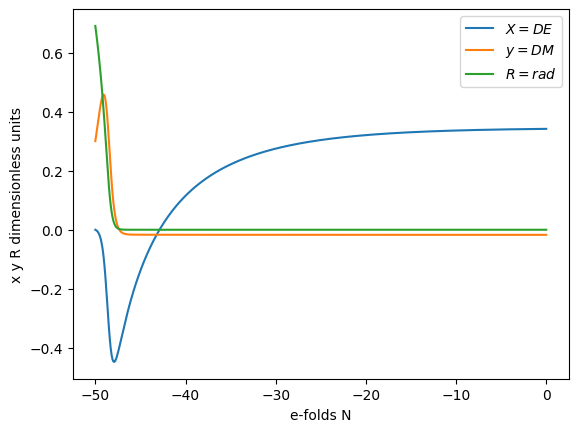

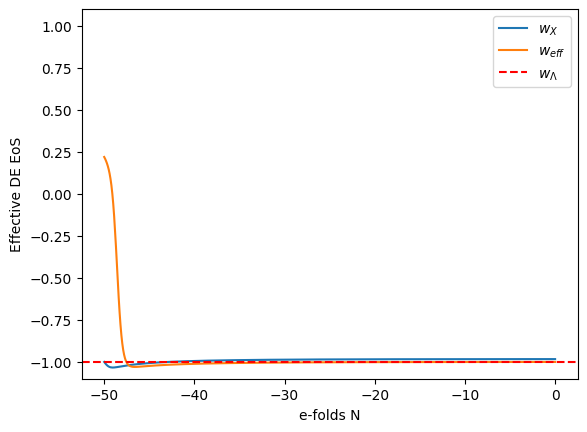

In [8]:
w,q =-0.95,0.05


def system(t,vars):
    x,y,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y-R)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y-R)+4*y*R #dynamic DM
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    
    return [dx,dy,dR]

simulationTime=np.linspace(-50,0,500)
solution = solve_ivp(system,[-50,0],[0.00001, 0.3, 0.69],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
R=solution.y[2]
wx= ((1+w)*x-1+y+R)/(1-y-R)
weff=(1+w)*x+4/3 *R +y-1


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.plot(simulationTime, R, label=r'$R=rad$')
plt.xlabel('e-folds N')
plt.ylabel('x y R dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Final x,y,R: 3.359673140791572e-07 -1.6801301177866347e-08 0.9999990255213875


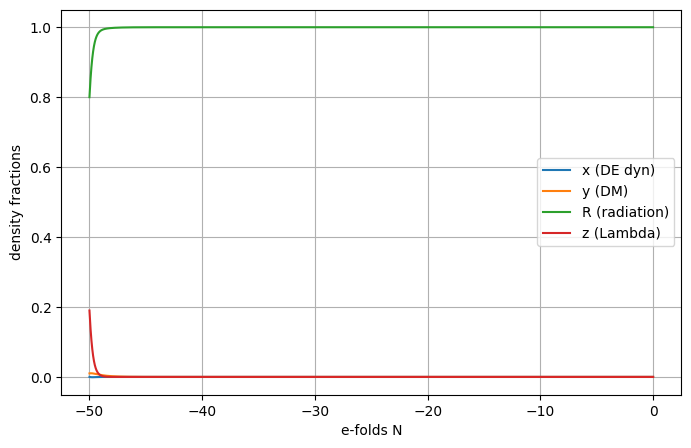

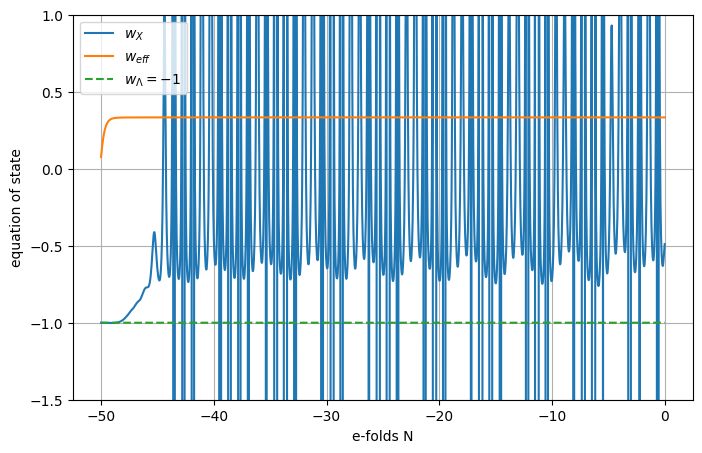

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# parameters
w = -0.95
q = 0.05

# -----------------------------
# SYSTEM (correct + stable form)
# -----------------------------
def system(N, vars):
    x, y, R = vars

    # Friedmann constraint
    z = 1 - x - y - R

    # interaction
    Q = q * (x + z - y)   # = q(1 - 2y - R)

    # H'/H effective term
    Hprime_over_H = (1 + w)*x + y + (4/3)*R

    dx = -3*(1+w)*x + Q + 3*x*Hprime_over_H
    dy = -3*y - Q + 3*y*Hprime_over_H
    dR = -4*R + 3*R*Hprime_over_H

    return [dx, dy, dR]


# -----------------------------
# TIME GRID
# -----------------------------
N = np.linspace(-50, 0, 2000)

# -----------------------------
# INITIAL CONDITIONS (stable)
# radiation dominated early universe
# -----------------------------
y0 = [1e-4, 0.01, 0.8]  # x, y, R

# -----------------------------
# SOLVE (IMPORTANT FIX)
# integrate forward in stable direction
# -----------------------------
sol = solve_ivp(
    system,
    [0, -50],          # reversed time for stability
    y0,
    t_eval=N[::-1],    # match reversed time
    method='RK45',
    rtol=1e-6,
    atol=1e-6
)

# reverse back
x = sol.y[0]
y = sol.y[1]
R = sol.y[2]

# -----------------------------
# DERIVED VARIABLES
# -----------------------------
z = 1 - x - y - R

# DE equation of state (stable form)
wx = ((1+w)*x + y + R - 1) / (1 - y - R + 1e-6)

# effective EOS
weff = (1+w)*x + y + (4/3)*R - 1

w_lambda = -np.ones_like(N)

# -----------------------------
# CHECK SOLVER SUCCESS
# -----------------------------
if not sol.success:
    print("Solver warning:", sol.message)

print("Final x,y,R:", x[-1], y[-1], R[-1])

# -----------------------------
# PLOTS
# -----------------------------

# densities
plt.figure(figsize=(8,5))
plt.plot(N, x, label='x (DE dyn)')
plt.plot(N, y, label='y (DM)')
plt.plot(N, R, label='R (radiation)')
plt.plot(N, z, label='z (Lambda)')
plt.xlabel("e-folds N")
plt.ylabel("density fractions")
plt.legend()
plt.grid()

# EOS
plt.figure(figsize=(8,5))
plt.plot(N, wx, label=r'$w_X$')
plt.plot(N, weff, label=r'$w_{eff}$')
plt.plot(N, w_lambda, '--', label=r'$w_\Lambda=-1$')
plt.xlabel("e-folds N")
plt.ylabel("equation of state")
plt.ylim(-1.5, 1.0)
plt.legend()
plt.grid()

plt.show()